In [1]:
#!uv init
#!uv add librosa soundfile numpy matplotlib IPython pandas scikit-learn

## Analysing Arctic Bird Sounds

This work used the ArcticSounds dataset, an open-access multi-year, multi-site strongly detailed annotated dataset of bird songs and calls. The data is present in https://osf.io/b9trx/overview.

In [2]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import os
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from sklearn.model_selection import GroupShuffleSplit
from collections import Counter

In [ ]:
# Replace with the path to your directory containing FLAC files
data_dir = 'DataS1/audio_annots'

output_dir = 'output_analysis' 
os.makedirs(output_dir, exist_ok=True)

# List all .flac files in the directory
flac_files = [f for f in os.listdir(data_dir) if f.endswith('.flac')]
print(len(flac_files))

2280



--- Exploring file: 2018_CORI-1_20180611-020000_1.flac ---
Original Sample Rate (sr): 16000 Hz
Audio duration: 30.00 seconds
Number of samples: 480000
Min amplitude: -1.0000, Max amplitude: 0.9979


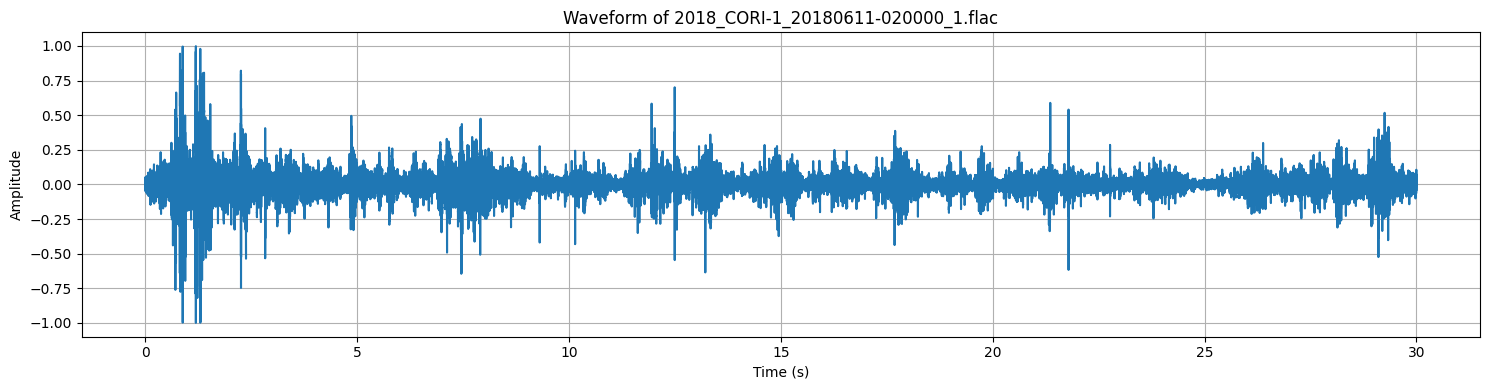

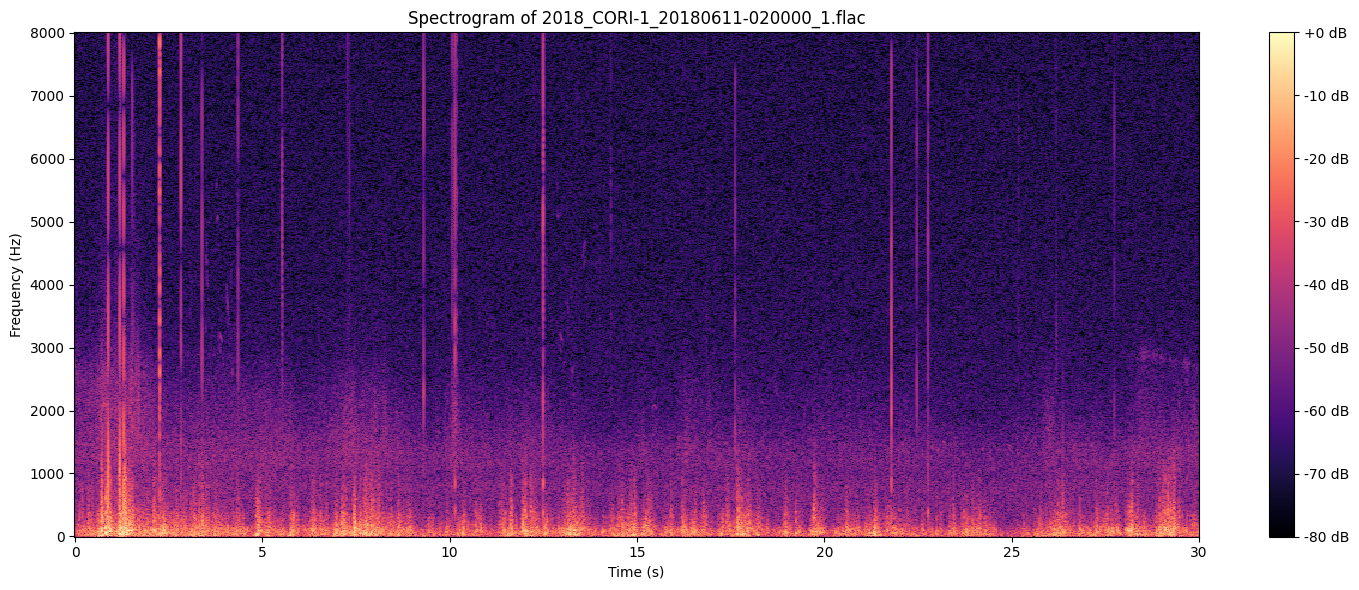


--- Exploring file: 2018_CORI-1_20180611-020000_10.flac ---
Original Sample Rate (sr): 16000 Hz
Audio duration: 30.00 seconds
Number of samples: 480000
Min amplitude: -0.9956, Max amplitude: 1.0000


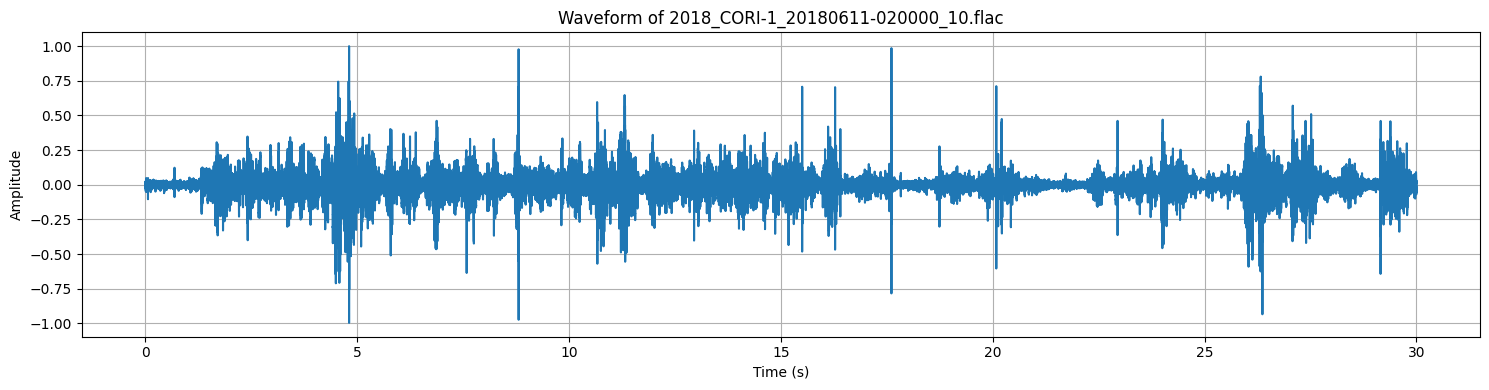

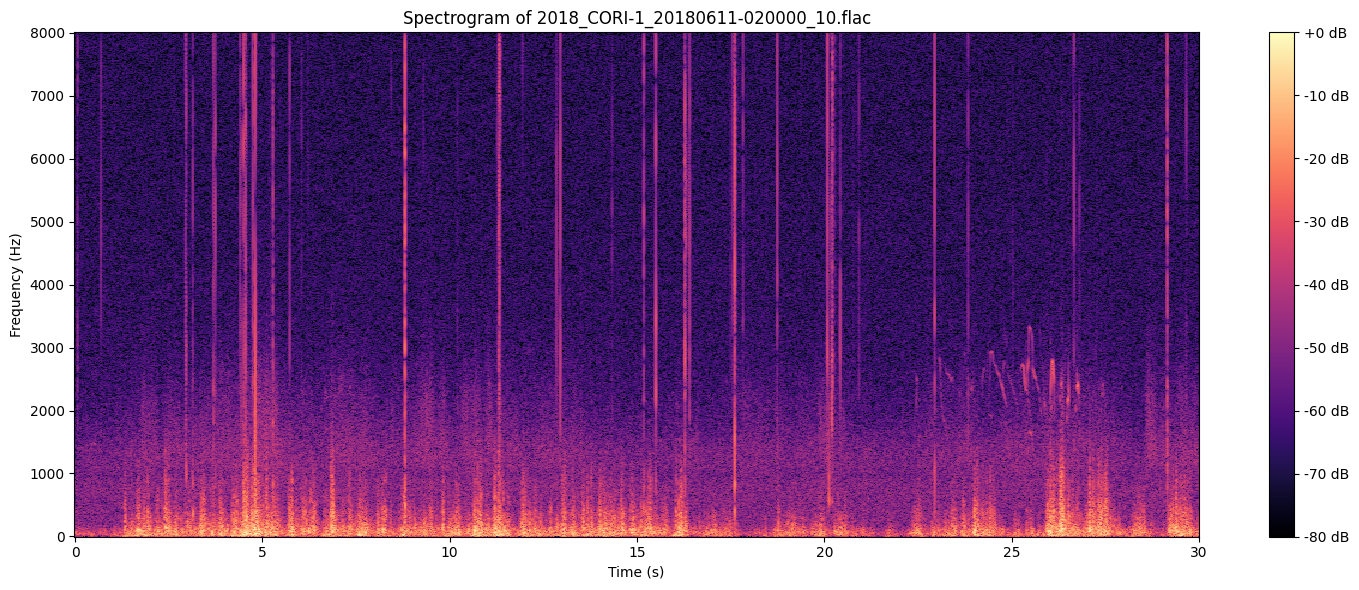


--- Exploring file: 2018_CORI-1_20180611-020000_2.flac ---
Original Sample Rate (sr): 16000 Hz
Audio duration: 30.00 seconds
Number of samples: 480000
Min amplitude: -1.0000, Max amplitude: 0.9992


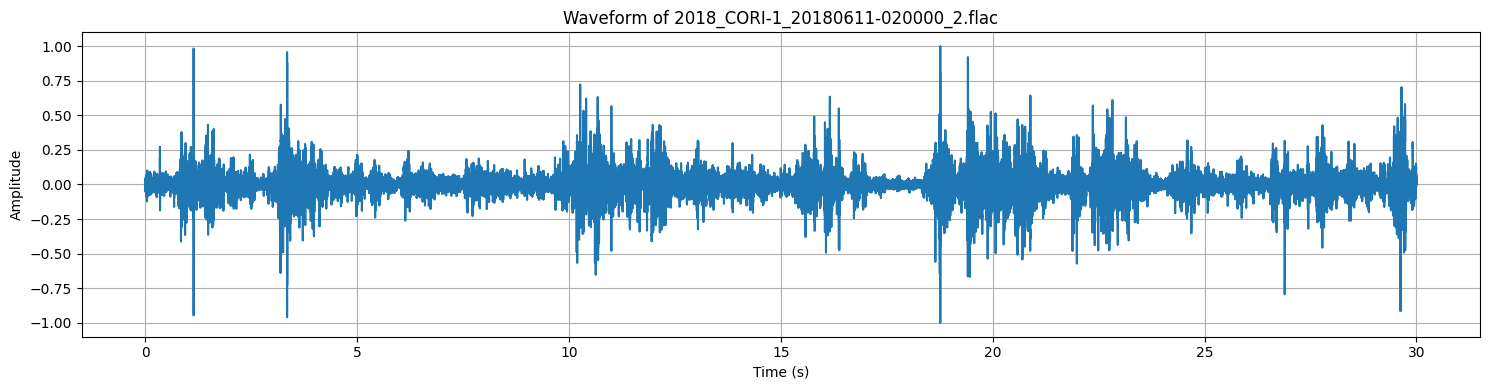

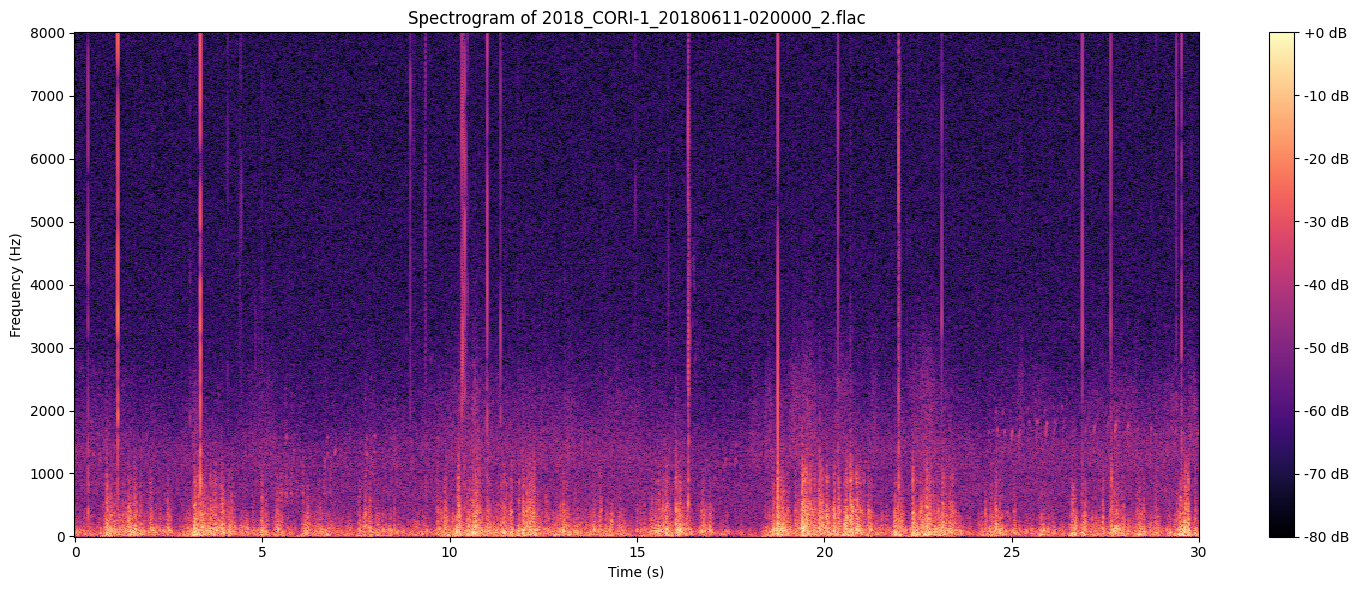

In [ ]:
# Let's explore the first few files as examples
example_files = flac_files[:min(3, len(flac_files))] # Take up to 3 examples

for i, filename in enumerate(example_files):
    filepath = os.path.join(data_dir, filename)
    print(f"\n--- Exploring file: {filename} ---")

    # Load audio using soundfile to read without resampling
    y, sr = sf.read(filepath, dtype='float32')
    print(f"Original Sample Rate (sr): {sr} Hz")
    print(f"Audio duration: {len(y) / sr:.2f} seconds")
    print(f"Number of samples: {len(y)}")
    print(f"Min amplitude: {np.min(y):.4f}, Max amplitude: {np.max(y):.4f}")

    # Plot waveform
    plt.figure(figsize=(15, 4))
    plt.plot(np.linspace(0, len(y)/sr, len(y)), y)
    plt.title(f'Waveform of {filename}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'waveform_{i}.png'))
    plt.show()

    # Plot spectrogram

    # Displays frequency content over time. 
    # Visually represents calls, songs, and other sounds.
    
    # Convert to mono if stereo
    if y.ndim > 1:
        y = np.mean(y, axis=1)

    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    plt.figure(figsize=(15, 6))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Spectrogram of {filename}')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'spectrogram_{i}.png'))
    plt.show()

Get file pairs (audio - bird tags)

In [5]:
# --- Helper Function to get file pairs ---
def get_audio_tag_pairs():
    """
    Identifies corresponding audio and tag files.
    Assumes tag files are named: {audio_filename_without_ext}-tags.csv
    """
    audio_files = flac_files
    Files_path = 'DataS1/audio_annots'


    file_pairs = []
    for audio_fname in audio_files:
        audio_name_no_ext = os.path.splitext(audio_fname)[0]
        tag_fname = f"{audio_name_no_ext}-tags.csv"
        tag_fpath = os.path.join(Files_path, tag_fname)
        audio_fpath = os.path.join(Files_path, audio_fname)

        if os.path.exists(tag_fpath):
            file_pairs.append((audio_fname, tag_fname))
        else:
            print(f"Warning: No tag file found for {audio_fname} (expected {tag_fpath})")
    return file_pairs

In [6]:
# Get all audio-tag file pairs
file_pairs = get_audio_tag_pairs()
file_pairs[0]

('2018_CORI-1_20180611-020000_1.flac',
 '2018_CORI-1_20180611-020000_1-tags.csv')

#### Quality Issue

Background Noise: There is significant constant noise (e.g., wind) that might obscure target sounds.


#### **General Preprocessing Strategy:**

1. **Load Audio:** Load the original audio samples.

2.  **Resampling:** All audio will be resampled to a consistent `22050 Hz`. This standard rate balances information content with computational cost for many bioacoustics tasks.

3.  **Mono Conversion:** Many feature extraction algorithms and ML models expect mono input. Averaging channels is a simple and effective way to convert stereo to mono.

4.  **Normalization:** Decision: Ensures that all audio segments have a similar amplitude range (e.g., between -1.0 and 1.0). This prevents recordings made at different volumes from disproportionately influencing a model.

0.  **Future work - Noise Reduction:** With a specific, pervasive noise (like wind, hum) identified across multiple recordings, a targeted filter or noise reduction algorithm should be applied.

5.  **Process annotations:** Include the bird anotatitions present in the csv files in the audio data.

6.  **Feature Extraction:** Decision: MFCCs are widely used in speech and audio processing. They represent the short-term power spectrum of a sound, based on a linear cosine transform of a log power spectrum on a nonlinear Mel scale of frequency. They are good at capturing timbral characteristics.

Parameters:
- n_mfcc: Number of Mel-frequency cepstral coefficients to return. More coefficients capture finer detail.
- hop_length: The number of samples between successive frames. Smaller hop_length means more frames and finer temporal resolution.
- n_fft: The length of the FFT window. A longer window gives finer frequency resolution but coarser temporal resolution.

Effect: Transforms the raw audio waveform into a sequence of feature vectors, one for each short time frame.

There are also other features that could have been considered for the analysis. But for the sake of simplicity, we will follow just with the above.


In [ ]:
#  Documenting Quality Issues, Artifacts, and Preprocessing Decisions

# Common parameters for all files
target_sr = 22050 # Target sample rate for consistency
n_mfcc = 40 # Number of MFCCs to extract
hop_length = 512 # Number of samples between successive frames
n_fft = 2048 # Length of the FFT window

# Initialize lists to store segment extracted data
all_features = []
all_labels = []
all_segment_info = []

dataset_features = {}
Audio_data = {}

for audio_file, tags_file in file_pairs:
    filepath = os.path.join(data_dir, audio_file)
    filepath_tags = os.path.join(data_dir, tags_file)
    audio_id = os.path.splitext(audio_file)[0]
    print(f"Processing file: {audio_file}")

    # 1. Load Audio
    y, sr_orig = sf.read(filepath, dtype='float32')
    y_original = y

    # 2. Resampling
    if sr_orig != target_sr:
        y = librosa.resample(y, orig_sr=sr_orig, target_sr=target_sr)
        sr = target_sr
    else:
        sr = sr_orig

    # 3. Mono Conversion (if stereo)
    if y.ndim > 1:
        y = np.mean(y, axis=1)

    # 4. Normalization (Peak Normalization to [-1, 1])
    y = librosa.util.normalize(y)

    # 5. Process annotations
    # Load the annotations
    tags_df = pd.read_csv(filepath_tags)

    These_segments_info = []
    These_segments_audio = []

    for index, row in tags_df.iterrows():
        start_time = row['start']
        end_time = row['end']
        tag = str(row['tag']) # Ensure tag is a string

        # Convert start and end times to sample indices
        start_sample = int(start_time * target_sr)
        end_sample = int(end_time * target_sr)

        if end_sample > len(y):

            # Clip end_sample to audio length if it goes beyond
            original_end_sample = end_sample
            end_sample = len(y)

        audio_segment = y[start_sample:end_sample]

        if len(audio_segment) > 0:

            # Add a small epsilon to avoid issues with extremely short segments
            mfccs = librosa.feature.mfcc(y=audio_segment, sr=target_sr, n_mfcc=n_mfcc)
            mfccs_mean = np.mean(mfccs.T, axis=0)

            segment_data = {
                'original_audio_file': audio_file,
                'tag': tag,
                'mfccs': mfccs,
                'mfccs_mean': mfccs_mean,
                'start_time_s': start_time,
                'end_time_s': end_time,
                'duration_s': end_time - start_time
            }

            all_features.append(mfccs_mean)
            all_labels.append(tag)
            all_segment_info.append(segment_data)

            These_segments_info.append(segment_data)
            These_segments_audio.append((tag, audio_segment))

    # 6. Feature Extraction (e.g., MFCCs)
    if len(y) == 0:
        print(f"Warning: Audio for {audio_file} became empty after trimming. Skipping feature extraction.")
        continue

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length, n_fft=n_fft)

    # Store features and any other relevant metadata
    dataset_features[audio_id] = {
        'mfccs': mfccs,
        'original_sr': sr_orig,
        'processed_sr': sr,
        'duration_s': len(y) / sr,
        'Segments_Info': These_segments_info
    }

    Audio_data[audio_id] = {
        'original audio': y_original,
        'updated audio': y,
        'segments audio': These_segments_audio
    }

print("\n--- Preprocessing and Feature Extraction Complete ---")
print(f"Processed {len(dataset_features)} files successfully.")


In [8]:
first_id = list(dataset_features.keys())[0]
print(f"\nExample for the first entry '{first_id}'")
print(f"MFCC shape : {dataset_features[first_id]['mfccs'].shape}")
print(f"Sample Rate (sr) : Original - {dataset_features[first_id]['original_sr']} ; Processed - {dataset_features[first_id]['processed_sr']}")
print(f"Duration : {dataset_features[first_id]['duration_s']}")
print(f"MFCCs :\n{dataset_features[first_id]['mfccs'][:, :5]}")


Example for the first entry '2018_CORI-1_20180611-020000_1'
MFCC shape : (40, 1292)
Sample Rate (sr) : Original - 16000 ; Processed - 22050
Duration : 30.0
MFCCs :
[[-2.94564209e+02 -2.74777191e+02 -2.79854553e+02 -2.81603516e+02
  -2.72384949e+02]
 [ 1.17714783e+02  1.34446320e+02  1.34404800e+02  1.33893005e+02
   1.45496399e+02]
 [-2.51226501e+01 -3.14687119e+01 -2.92064896e+01 -2.67026844e+01
  -2.32252178e+01]
 [ 2.80362129e+01  3.06451454e+01  3.13902855e+01  3.41691360e+01
   3.60754623e+01]
 [ 1.43340931e+01  9.45043564e+00  1.36531172e+01  1.94495296e+01
   2.26962738e+01]
 [ 2.03911171e+01  2.16379623e+01  2.14291134e+01  2.82773857e+01
   3.11542969e+01]
 [ 2.82873297e+00 -9.35041606e-01 -4.02076817e+00 -3.83289993e-01
   1.19601572e+00]
 [ 1.41146641e+01  1.89609375e+01  2.12572823e+01  2.72035484e+01
   2.21758385e+01]
 [-1.09623528e+01 -2.63537693e+00  3.71454883e+00  4.89032078e+00
  -5.93482196e-01]
 [-2.90020013e+00  1.69900084e+00  6.20077419e+00  7.20641434e-01
  -3

In [9]:
display(Audio(data=Audio_data[first_id]['original audio'], rate=dataset_features[first_id]['original_sr']))

In [10]:
display(Audio(data=Audio_data[first_id]['updated audio'], rate=dataset_features[first_id]['processed_sr']))

### Data Splitting Strategy

### Summary of Workflow:

- *Define Groups:* Each unique file_name becomes a group.
Define Stratification Labels for Groups: For each unique file, determining a representative label.

- *Perform File-Level Stratified Group Split:* Use GroupShuffleSplit (or GroupKFold) with the unique file_name as groups and the representative file labels for stratification, splitting into training, validation, and test sets of file paths.

- *Filter Segments:* Distributing the extracted segment features and labels (X and y) into X_train, y_train, X_val, y_val, and X_test, y_test based on which file their parent audio belongs to.

In [ ]:
# 1. Map segments to their original file paths and get unique file paths

#  To prevent data leakage. All segments from one file must stay in one split.
segment_files = [info['original_audio_file'] for info in all_segment_info]

# These unique files are our 'groups' for the split.
unique_files = list(set(segment_files))

In [ ]:
# 2. Determine a "representative label" for each unique file for stratification

# To address class imbalance. We want to ensure that if a rare bird species is present in only a few files, those files are evenly distributed

file_labels = {}

for file_path in unique_files:

    # Find all actual bird tags/labels present in this specific file
    relevant_labels = [info['tag'] for info in all_segment_info
                       if info['original_audio_file'] == file_path]

    if relevant_labels:
        # If the file has annotations, find the most common one to represent it. This is one simple way to "stratify" files. More complex ways could use all labels.
        most_common_label = Counter(relevant_labels).most_common(1)[0][0]
        file_labels[file_path] = most_common_label

    else:
        # If a file has no bird annotations
        file_labels[file_path] = "NO_BIRD_ANNOTATIONS"

# Convert the dictionary into ordered NumPy arrays suitable for scikit-learn's splitter.
stratify_labels = np.array([file_labels[f] for f in unique_files])
file_paths_array = np.array(unique_files)

print(stratify_labels) 

In [ ]:
# 3. Perform the stratified group split

# Split files into Training+Validation vs. Test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

split_indices = gss_test.split(X=np.zeros(len(unique_files)), groups=file_paths_array, y=stratify_labels)
train_val_idx, test_idx = next(split_indices) 

train_val_files = file_paths_array[train_val_idx] 
test_files = file_paths_array[test_idx]
           
print(f"Total files: {len(unique_files)}")
print(f"Files in Train+Validation: {len(train_val_files)}")
print(f"Files in Test: {len(test_files)}")


# Split the Training+Validation files into actual Training vs. Validation
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

# Create new 'stratify_labels' only for the files currently in 'train_val_files'.
train_val_stratify_labels = np.array([file_labels[f] for f in train_val_files])

split_indices_val = gss_val.split(X=np.zeros(len(train_val_files)), groups=train_val_files, y=train_val_stratify_labels)
train_idx, val_idx = next(split_indices_val)

train_files = train_val_files[train_idx] 
val_files = train_val_files[val_idx]
     
print(f"Files in Training: {len(train_files)}")
print(f"Files in Validation: {len(val_files)}")

In [15]:
# 4. Filter 'X' (features) and 'y' (labels) based on these file lists

X_train_list, y_train_list = [], [] 
X_val_list, y_val_list = [], []     
X_test_list, y_test_list = [], []   

# Loop through every single segment's info extracted earlier
for i, info in enumerate(all_segment_info):
    current_file = info['original_audio_file']
    X = info['mfccs']
    y = info['tag']

    # Check which file list this segment's parent file belongs to
    if current_file in train_files:
        X_train_list.append(X) 
        y_train_list.append(y) 
        
    elif current_file in val_files:
        X_val_list.append(X)  
        y_val_list.append(y)

    elif current_file in test_files:
        X_test_list.append(X) 
        y_test_list.append(y)


--- Splitting Files into Train/Validation/Test Sets ---
Total files: 1509
Files in Train+Validation: 1207
Files in Test: 302
Files in Training: 905
Files in Validation: 302

--- Assigning Features and Labels to Splits ---
Total segments: 40
Segments in Training set (X_train, y_train): 7968
Segments in Validation set (X_val, y_val): 2534
Segments in Test set (X_test, y_test): 2431


In [ ]:
print(f"Total segments: {len(X)}")
print(f"Segments in Training set (X_train, y_train): {len(X_train_list)}")
print(f"Segments in Validation set (X_val, y_val): {len(X_val_list)}")
print(f"Segments in Test set (X_test, y_test): {len(X_test_list)}")

Total segments: 40
Segments in Training set (X_train, y_train): 7968
Segments in Validation set (X_val, y_val): 2534
Segments in Test set (X_test, y_test): 2431


### Model Architecture Selection

For this bioacoustic dataset, where the goal is to identify bird species in audio recordings, a robust machine learning architecture is required. Given the nature of audio data and the task of classification/detection, a Convolutional Neural Network (CNN) architecture, a **ResNet (Residual Network)** would be an excellent starting point.

**Reasoning:**

*   **Feature Learning:** CNNs can automatically learn relevant features from the spectrograms that correspond to different bird calls, background noise, or silence, without requiring extensive manual feature engineering.
*   **Hierarchical Representation:** Deeper CNNs allow for learning increasingly abstract features, which is beneficial for distinguishing between subtle variations in bird vocalizations.
*   **Handling Complexity:** With multiple bird species and varying numbers of birds, the task requires a model capable of high-resolution feature extraction to differentiate between similar-sounding calls or identify multiple calls within the same window.

**Computational Requirements:**

##### Training

*   **GPU:** Highly recommended, if not essential. Training deep CNNs on spectrograms is computationally intensive. Modern GPUs are ideal.
*   **CPU:** Needed for data loading and preprocessing, but usually less of a bottleneck than the GPU. Multi-core CPUs are beneficial for parallel data loading.
*   **RAM:** 32GB+ is a good starting point, especially if processing large batches of spectrograms in memory or for extensive data augmentation.
*   **Storage:** Fast SSDs are beneficial for quickly loading audio files and spectrograms, preventing I/O bottlenecks.
*   **Time:** Training a ResNet from scratch or fine-tuning extensively can take hours to days depending on dataset size, model complexity, and GPU power.

##### Deployment

*   **Deployments:** For real-time inference on edge devices or less demanding applications, optimized models can run on CPUs. However, inference time will be higher than on a GPU.
*   **Memory:** Significantly less RAM than training, as only the model weights and inference data need to be loaded.

### Training Approach

1.  **Transfer Learning:** We can start with a pre-trained ResNet from a framework like PyTorch or TensorFlow.

2.  **Training:** Remove the original classification head of the ResNet and replace it with new layers suitable for the bioacoustic task. This new head would likely consist of:
    *   Global Average Pooling: Reduces spatial dimensions to a single feature vector.
    *   One or more Dense (Fully Connected) layers with ReLU activation.
    *   A final Dense layer with a `softmax` activation for multi-class classification (if predicting a single bird species per segment) or `sigmoid` activation for multi-label classification (if multiple bird species can be present in one segment).
    *  Initially, freeze the weights of the pre-trained ResNet backbone and train only the newly added. Afterwards, unfreeze some or all of the backbone layers and continue training with a much smaller learning rate.
